# Diabetic Retinopathy — Ensemble Fine-tuning Notebook

**Track:** Fine-tuning (pretrained torchvision / timm models)

**Metric:** AUC (area under the ROC curve)

**Submission:** `outputs/output_ensemble.csv` — 1000×1 DR scores

Run every cell top-to-bottom to reproduce results and generate the submission file.

---
## Pipeline overview

```
data/
  train.csv / val.csv / test.csv
  images/
        ↓
RetinopathyDataset  (right-eye mirror, CLAHE, augmentations)
WeightedRandomSampler  (balance DR vs No-DR)
        ↓
EnsembleModel  (EfficientNet-B2 + DenseNet-121 + TinyViT)
        ↓
Trainer  (AdamW + ReduceLROnPlateau + early stopping on val AUC)
        ↓
outputs/output_ensemble.csv
```

## 0 · Imports & reproducibility

In [1]:
%matplotlib inline
from __future__ import print_function, division

import os, random, csv, warnings
from zipfile import ZipFile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn import metrics

import torch
import torch.nn as nn

warnings.filterwarnings('ignore') 

# ── Import project modules ───────────────────────────────────────────────────
from utils.config import Config as cfg

from utils.data_processing import (
    RetinopathyDataset,
    get_dataloader,
    build_train_transforms,
    build_eval_transforms,
)
from src.model   import BaseModel, EnsembleModel
from utils.trainer import Trainer

# ── Reproducibility ───────────────────────────────────────────────────────────
random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
torch.cuda.manual_seed_all(cfg.seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

print(f'Device : {cfg.device}')
print(f'PyTorch: {torch.__version__}')

Device : cuda
PyTorch: 2.10.0+cu128


---
## 1 · Exploratory Data Analysis (EDA)

In [2]:
# ─── Load CSVs ───────────────────────────────────────────────────────────────
train_df = pd.read_csv(cfg.train_csv, dtype={'id': str, 'eye': int, 'label': int})
val_df   = pd.read_csv(cfg.val_csv,   dtype={'id': str, 'eye': int, 'label': int})
test_df  = pd.read_csv(cfg.test_csv,  dtype={'id': str, 'eye': int, 'label': int})

print(f'Train: {len(train_df):>5} samples')
print(f'Val  : {len(val_df):>5} samples')
print(f'Test : {len(test_df):>5} samples')
train_df.head()

Train:  2000 samples
Val  :   500 samples
Test :  1000 samples


,id,eye,label
0,00000,0,0
1,00001,1,0
2,00002,1,2
3,00003,1,0
4,00004,0,0


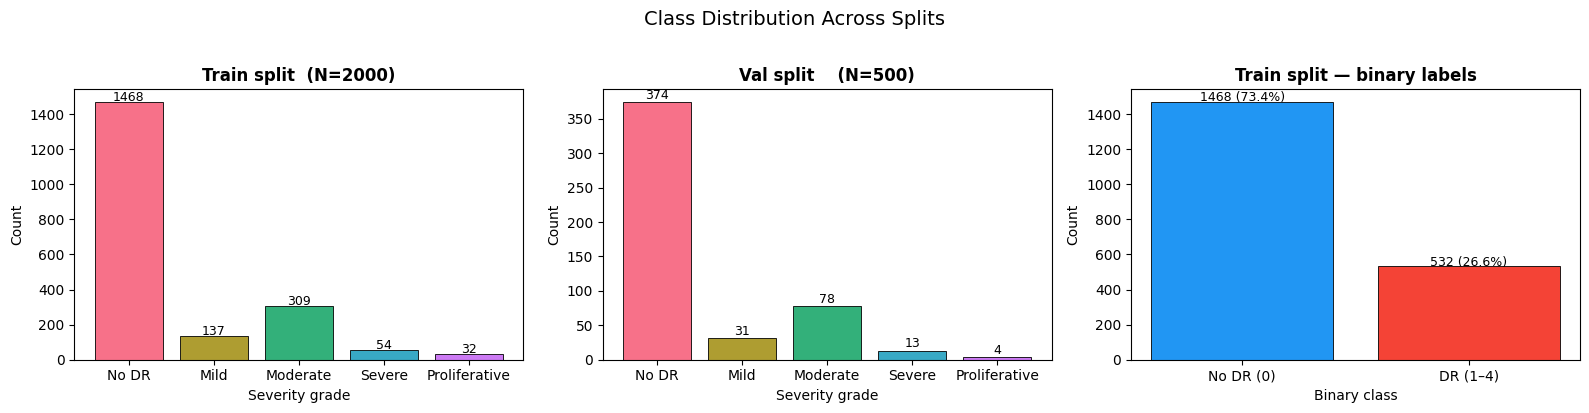

Class imbalance ratio  No-DR : DR = 0.73 : 0.27
Implied pos_weight            = 2.759


In [3]:
# ─── Class distribution ───────────────────────────────────────────────────────
severity_labels = {0: 'No DR', 1: 'Mild', 2: 'Moderate', 3: 'Severe', 4: 'Proliferative'}
binary_labels   = {0: 'No DR (0)', 1: 'DR (1–4)'}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
palette   = sns.color_palette('husl', 5)

for ax, (df, title) in zip(axes, [
    (train_df, 'Train split  (N=2000)'),
    (val_df,   'Val split    (N=500)'),
]):
    counts = df['label'].value_counts().sort_index()
    ax.bar([severity_labels[i] for i in counts.index], counts.values,
           color=palette[:len(counts)], edgecolor='k', linewidth=0.6)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Severity grade')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 5, str(v), ha='center', fontsize=9)

# Binary view
ax = axes[2]
binary_counts = (train_df['label'] > 0).value_counts().sort_index()
ax.bar([binary_labels[i] for i in binary_counts.index], binary_counts.values,
       color=['#2196F3', '#F44336'], edgecolor='k', linewidth=0.6)
ax.set_title('Train split — binary labels', fontsize=12, fontweight='bold')
ax.set_xlabel('Binary class')
ax.set_ylabel('Count')
for i, v in enumerate(binary_counts.values):
    ax.text(i, v + 5, f'{v} ({100*v/len(train_df):.1f}%)', ha='center', fontsize=9)

plt.suptitle('Class Distribution Across Splits', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

pos_frac = (train_df['label'] > 0).mean()
print(f'Class imbalance ratio  No-DR : DR = {1-pos_frac:.2f} : {pos_frac:.2f}')
print(f'Implied pos_weight            = {(1-pos_frac)/pos_frac:.3f}')

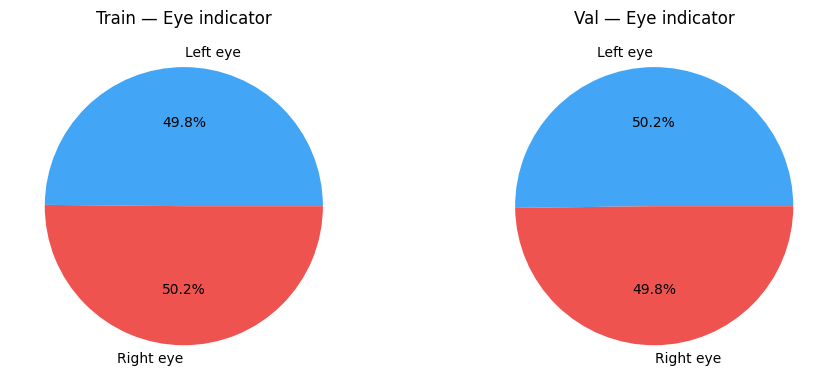

In [4]:
# ─── Eye indicator distribution ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (df, title) in zip(axes, [
    (train_df, 'Train'),
    (val_df,   'Val'),
]):
    counts = df['eye'].value_counts().sort_index()
    ax.pie(counts.values, labels=['Left eye', 'Right eye'],
           autopct='%1.1f%%', colors=['#42A5F5', '#EF5350'])
    ax.set_title(f'{title} — Eye indicator')

plt.tight_layout()
plt.show()

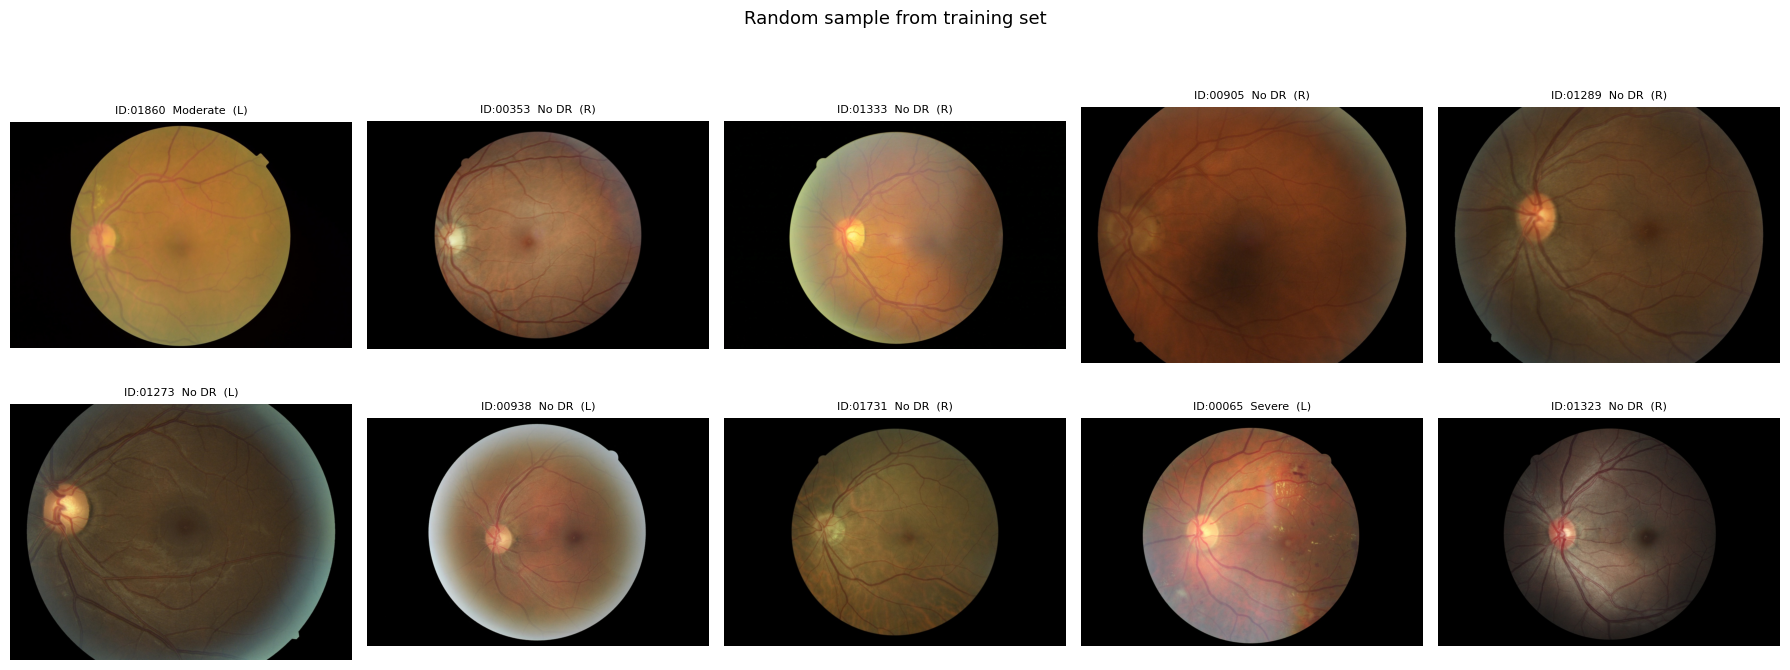

In [5]:
# ─── Sample image grid ───────────────────────────────────────────────────────
from skimage import io as skio, util as skutil

n_samples = 10
sample_df = train_df.sample(n_samples, random_state=cfg.seed).reset_index(drop=True)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, row in sample_df.iterrows():
    img_path = os.path.join(cfg.images_dir, row['id'] + '.jpg')
    img = skio.imread(img_path)
    if row['eye'] == 1:
        img = img[:, ::-1, :]
    axes[i].imshow(img)
    grade = severity_labels[row['label']]
    axes[i].set_title(f"ID:{row['id']}  {grade}  ({'R' if row['eye']==1 else 'L'})",
                      fontsize=8)
    axes[i].axis('off')

plt.suptitle('Random sample from training set', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

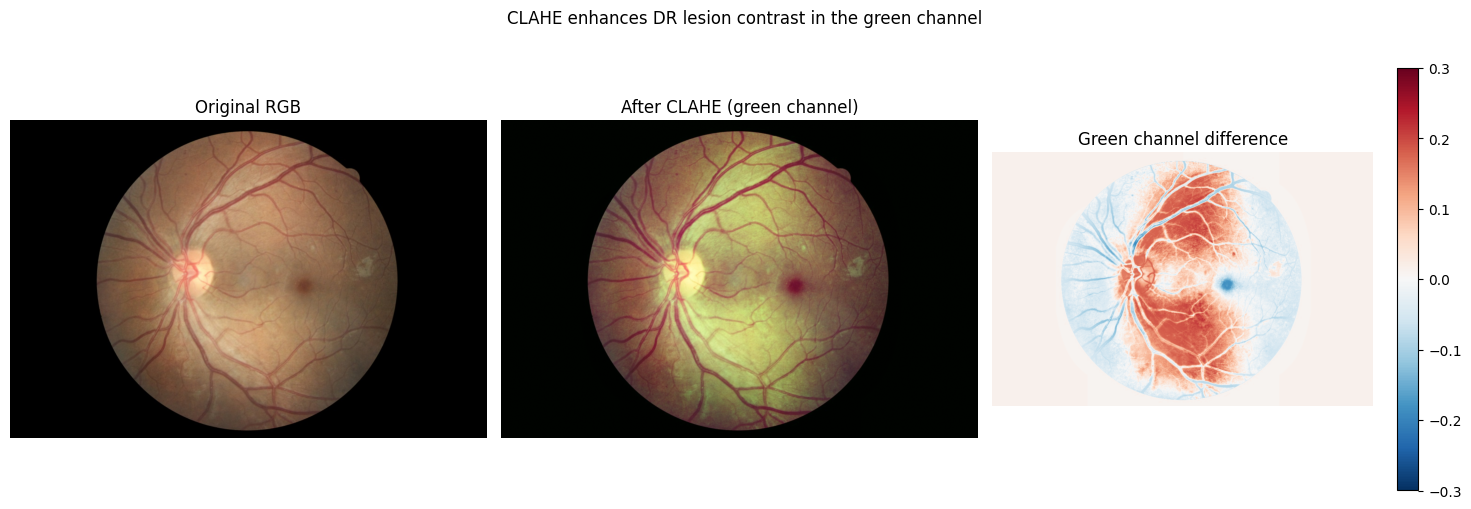

In [6]:
# ─── CLAHE effect visualisation ───────────────────────────────────────────────
from utils.data_processing import apply_clahe_green

row = train_df[train_df['label'] > 0].sample(1, random_state=1).iloc[0]
img = skutil.img_as_float(skio.imread(os.path.join(cfg.images_dir, row['id'] + '.jpg')))
img_clahe = apply_clahe_green(img)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img)
axes[0].set_title('Original RGB')
axes[1].imshow(img_clahe)
axes[1].set_title('After CLAHE (green channel)')
# Difference map on green channel
diff = img_clahe[:,:,1].astype(float) - img[:,:,1].astype(float)
im = axes[2].imshow(diff, cmap='RdBu_r', vmin=-0.3, vmax=0.3)
axes[2].set_title('Green channel difference')
plt.colorbar(im, ax=axes[2])
for ax in axes:
    ax.axis('off')
plt.suptitle('CLAHE enhances DR lesion contrast in the green channel',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## 2 · DataLoaders

In [7]:
# Set max_size=200 for a quick dev run; 0 = full dataset
MAX_SIZE = 0

train_dataset, train_loader = get_dataloader(
    cfg.train_csv, is_train=True,  batch_size=cfg.batch_size, max_size=MAX_SIZE)

val_dataset, val_loader = get_dataloader(
    cfg.val_csv,   is_train=False, batch_size=cfg.batch_size * 2)

_, test_loader = get_dataloader(
    cfg.test_csv,  is_train=False, batch_size=cfg.batch_size * 2)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

# Verify batch shapes
batch = next(iter(train_loader))
print(f"\nBatch image shape : {batch['image'].shape}")
print(f"Batch label shape : {batch['label'].shape}")
print(f"Label distribution: {batch['label'].float().mean():.2f} (expect ≈0.5 with sampler)")

[DataLoader] train.csv | No-DR: 1,468 | DR: 532 | WeightedSampler ratio ≈ 1:2.76
Train batches : 62
Val   batches : 8
Test  batches : 16

Batch image shape : torch.Size([32, 3, 224, 224])
Batch label shape : torch.Size([32])
Label distribution: 0.56 (expect ≈0.5 with sampler)


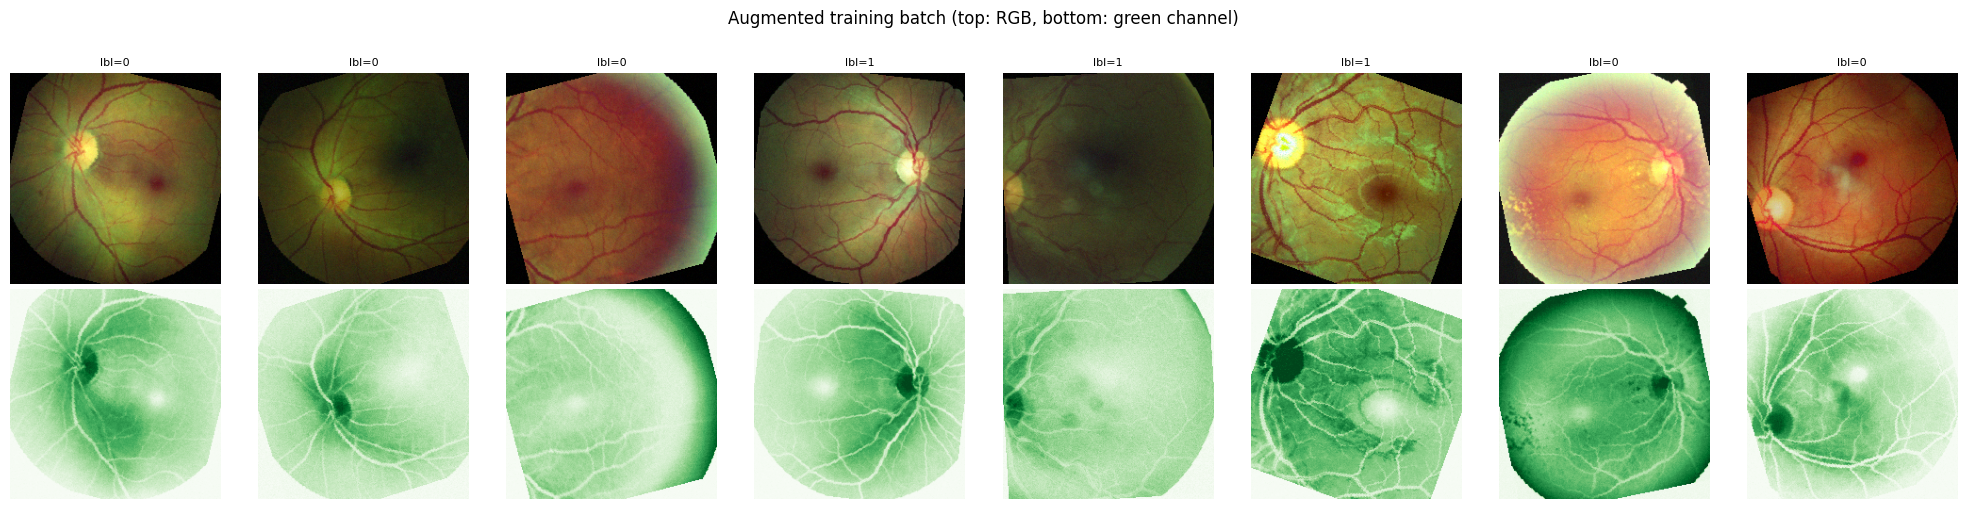

In [8]:
# ─── Augmentation visualisation ──────────────────────────────────────────────
# Compare the same image before / after the augmentation pipeline
from skimage import util as skutil

fig, axes = plt.subplots(2, 8, figsize=(20, 5))
imgs = batch['image'][:8]   # first 8 images from the augmented batch

mean = np.array(cfg.pixel_mean)[:, None, None]
std  = np.array(cfg.pixel_std)[:, None, None]

for i in range(8):
    # De-normalise for display
    img_np = (imgs[i].numpy() * std + mean).transpose(1, 2, 0)
    img_np = np.clip(img_np, 0, 1)
    axes[0, i].imshow(img_np)
    axes[0, i].set_title(f"lbl={batch['label'][i].item()}", fontsize=8)
    axes[0, i].axis('off')
    # Green channel only
    axes[1, i].imshow(img_np[:, :, 1], cmap='Greens')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('RGB', fontsize=9)
axes[1, 0].set_ylabel('Green ch.', fontsize=9)
plt.suptitle('Augmented training batch (top: RGB, bottom: green channel)', y=1.01)
plt.tight_layout()
plt.show()

---
## 3 · Model instantiation

In [9]:
# ── Ensemble ─────────────────────────────────────────────────────────────────
random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)

ensemble = EnsembleModel(
    unfreeze_n=cfg.unfreeze_layers,
    pretrained=True,
)

# Sanity-check forward pass
with torch.no_grad():
    dummy = torch.zeros(2, 3, cfg.img_height, cfg.img_height)
    out   = ensemble(dummy)
    assert out.shape == (2, 1), f'Expected (2,1), got {out.shape}'
    print(f'\n✓ Forward pass OK  output shape: {out.shape}')
    print(f'  Sample probabilities: {out.squeeze().tolist()}')

[BaseModel] efficientnet_b2 | total=7,702,403  trainable=499,841
[BaseModel] densenet121 | total=6,954,881  trainable=2,159,105
[BaseModel] tiny_vit_21m_224.dist_in22k_ft_in1k | total=20,622,145  trainable=8,555,365
[EnsembleModel] Total trainable params: 11,214,311

✓ Forward pass OK  output shape: torch.Size([2, 1])
  Sample probabilities: [0.521888017654419, 0.4627794921398163]


---
## 4 · Training

In [10]:
# ── Trainer ───────────────────────────────────────────────────────────────────
trainer = Trainer(
    model        = ensemble,
    train_loader = train_loader,
    val_loader   = val_loader,
    pos_weight   = None,          # auto-computed from train labels
    lr           = cfg.learning_rate,
    weight_decay = cfg.weight_decay,
    device       = cfg.device,
)

print('\nOptimiser:', trainer.optimizer)
print('Scheduler:', trainer.scheduler)

[Trainer] Auto pos_weight: 972 neg / 1012 pos = 0.960
[Trainer] pos_weight = 0.9605
[Trainer] Loss: BCELoss (ensemble outputs probabilities)

Optimiser: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0003
    maximize: False
    weight_decay: 0.0001
)
Scheduler: <torch.optim.lr_scheduler.ReduceLROnPlateau object at 0x7d4ce42b6860>


In [11]:
# ── Run training loop ─────────────────────────────────────────────────────────
random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
torch.cuda.manual_seed_all(cfg.seed)

history = trainer.fit(
    num_epochs          = cfg.num_epochs,
    early_stopping = cfg.early_stopping,
    checkpoint_name     = 'best_ensemble.pth',
)


  Training on cuda  |  max epochs: 50
  Early stop patience: 10



train:   0%|                              0/62 [00:00<?] ?it/s

val:   0%|                              0/8 [00:00<?] ?it/s

Epoch [  1/50]  Train loss: 0.6164  AUC: 0.6837  |  Val loss: 0.5217  AUC: 0.7197  |  LR: 3.00e-04  [219.7s]
  ✓ New best val AUC: 0.7197  (saved → /home/pawn/Desktop/vision/AutomaticDiagnosisForDiabeticRetinopathy/results/checkpoints/best_ensemble.pth)


train:   0%|                              0/62 [00:00<?] ?it/s

...

val:   0%|                              0/8 [00:00<?] ?it/s

Epoch [ 18/50]  Train loss: 0.4262  AUC: 0.8856  |  Val loss: 0.4424  AUC: 0.7763  |  LR: 8.10e-06  [240.3s]


train:   0%|                              0/62 [00:00<?] ?it/s

val:   0%|                              0/8 [00:00<?] ?it/s

Epoch [ 19/50]  Train loss: 0.4234  AUC: 0.8884  |  Val loss: 0.4447  AUC: 0.7723  |  LR: 8.10e-06  [236.2s]

[EarlyStopping] No val AUC improvement for 10 epochs. Stopping at epoch 19.

  Training complete in 71m 24s
  Best epoch: 9  |  Best val AUC: 0.7920


---
## 5 · Training curves

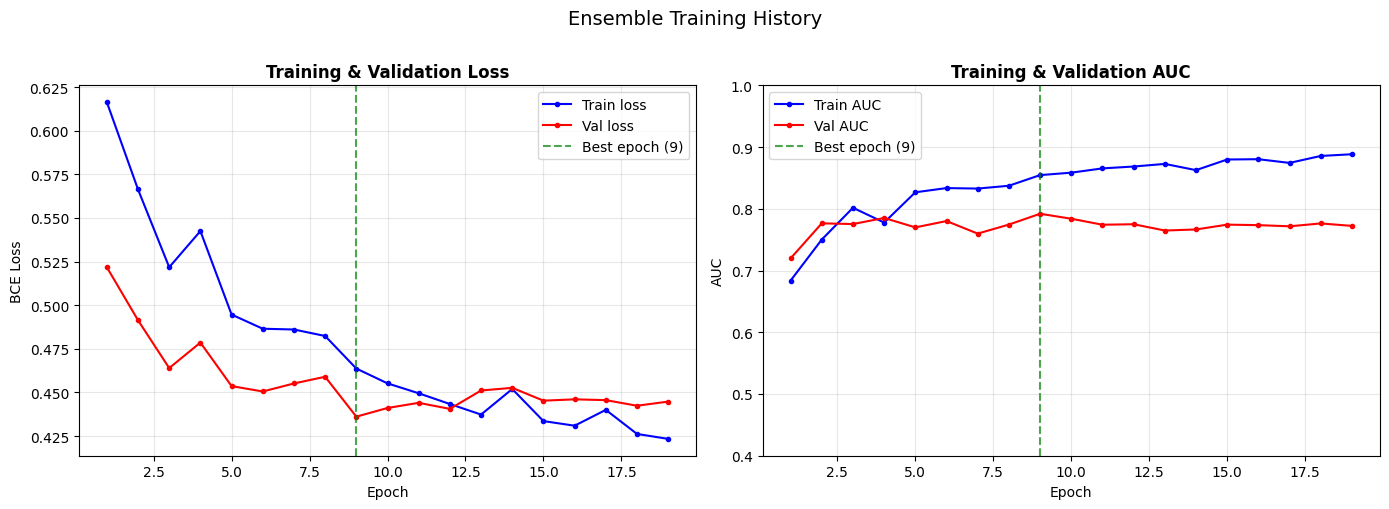

In [12]:
def plot_training_curves(history: dict, best_epoch: int | None = None):
    """Plot loss and AUC curves side-by-side."""
    epochs = range(1, len(history['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # ── Loss ──────────────────────────────────────────────────────────────────
    ax1.plot(epochs, history['train_loss'], 'b-o', markersize=3, label='Train loss')
    ax1.plot(epochs, history['val_loss'],   'r-o', markersize=3, label='Val loss')
    if best_epoch:
        ax1.axvline(best_epoch, color='green', linestyle='--', alpha=0.7,
                    label=f'Best epoch ({best_epoch})')
    ax1.set_title('Training & Validation Loss', fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('BCE Loss')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # ── AUC ───────────────────────────────────────────────────────────────────
    ax2.plot(epochs, history['train_auc'], 'b-o', markersize=3, label='Train AUC')
    ax2.plot(epochs, history['val_auc'],   'r-o', markersize=3, label='Val AUC')
    if best_epoch:
        ax2.axvline(best_epoch, color='green', linestyle='--', alpha=0.7,
                    label=f'Best epoch ({best_epoch})')
    ax2.set_title('Training & Validation AUC', fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('AUC')
    ax2.set_ylim(0.4, 1.0)
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.suptitle('Ensemble Training History', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

plot_training_curves(history, best_epoch=trainer.best_epoch)

---
## 6 · Validation evaluation (best-weight model)

Best-weight model  →  Val AUC: 0.7920


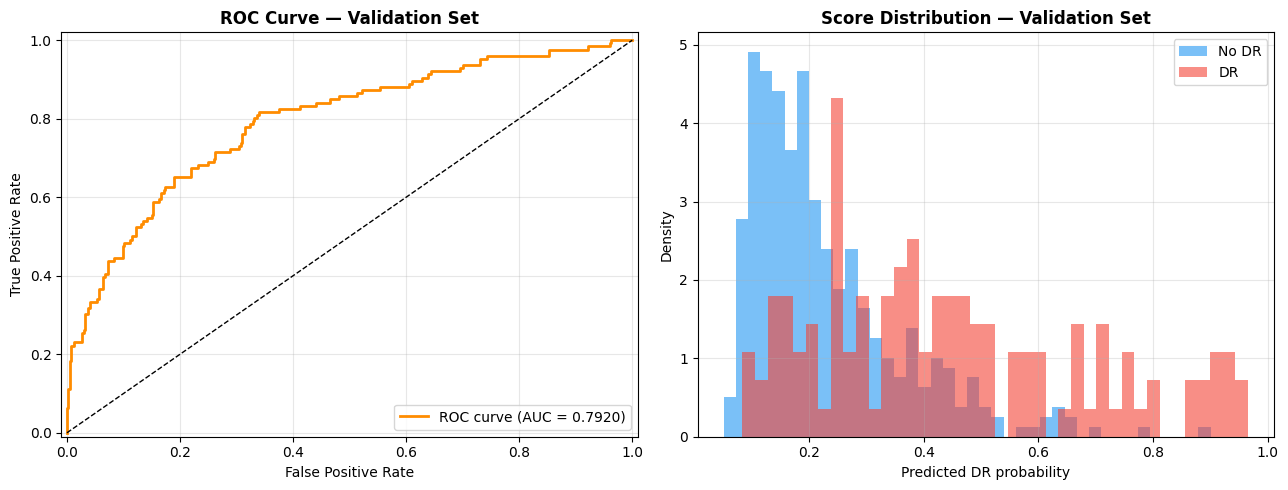

Optimal threshold (Youden's J): 0.2429
  TPR @ optimal: 0.8175
  FPR @ optimal: 0.3396

Confusion matrix at optimal threshold:
            Pred No-DR  Pred DR
True No-DR         247      127
True DR             23      103


In [13]:
val_auc, val_labels, val_probs = trainer.evaluate(val_loader)
print(f'Best-weight model  →  Val AUC: {val_auc:.4f}')

# ─── ROC curve ────────────────────────────────────────────────────────────────
fpr, tpr, thresholds = metrics.roc_curve(val_labels, val_probs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
axes[0].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (AUC = {val_auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlim([-0.01, 1.01])
axes[0].set_ylim([-0.01, 1.02])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Validation Set', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Score histogram
no_dr = val_probs[val_labels == 0]
dr    = val_probs[val_labels == 1]
axes[1].hist(no_dr, bins=40, alpha=0.6, color='#2196F3', label='No DR', density=True)
axes[1].hist(dr,    bins=40, alpha=0.6, color='#F44336', label='DR',    density=True)
axes[1].set_xlabel('Predicted DR probability')
axes[1].set_ylabel('Density')
axes[1].set_title('Score Distribution — Validation Set', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Optimal threshold (Youden's J)
j_scores   = tpr - fpr
opt_idx    = np.argmax(j_scores)
opt_thresh = thresholds[opt_idx]
print(f'Optimal threshold (Youden\'s J): {opt_thresh:.4f}')
print(f'  TPR @ optimal: {tpr[opt_idx]:.4f}')
print(f'  FPR @ optimal: {fpr[opt_idx]:.4f}')

# Confusion matrix at optimal threshold
preds = (val_probs >= opt_thresh).astype(int)
cm    = metrics.confusion_matrix(val_labels, preds)
print('\nConfusion matrix at optimal threshold:')
print(pd.DataFrame(cm, index=['True No-DR', 'True DR'],
                   columns=['Pred No-DR', 'Pred DR']))

In [15]:
# ─── Per-member AUC breakdown ─────────────────────────────────────────────────
print('Per-backbone validation AUC:')
member_names = ['EfficientNet-B2', 'DenseNet-121', 'TinyViT-21M']

ensemble.eval()
member_probs_list = [[] for _ in range(3)]
all_labels_list   = []

with torch.no_grad():
    for batch in val_loader:
        inputs = batch['image'].to(cfg.device)
        labs   = batch['label'].numpy().tolist()
        all_labels_list.extend(labs)
        logits = ensemble.member_logits(inputs)
        for k, logit in enumerate(logits):
            p = torch.sigmoid(logit).squeeze(1).cpu().numpy().tolist()
            member_probs_list[k].extend(p)

all_labels_arr = np.array(all_labels_list)
for name, probs in zip(member_names, member_probs_list):
    member_auc = metrics.roc_auc_score(all_labels_arr, np.array(probs))
    print(f'  {name:20s}: {member_auc:.4f}')

print(f'\n  Ensemble (avg)       : {val_auc:.4f}  ← should beat all individual members')

Per-backbone validation AUC:
  EfficientNet-B2     : 0.7226
  DenseNet-121        : 0.7580
  TinyViT-21M         : 0.7491

  Ensemble (avg)       : 0.7920  ← should beat all individual members


---
## 7 · Generate test predictions & submit

In [18]:
scores = trainer.test_inference(
    test_loader = test_loader,
    output_path = cfg.base_dir / "results" / "outputs" / "output_ft.csv",
)

print(f'\nOutput shape   : {scores.shape}   (expect 1000 × 1)')
print(f'Score range    : [{scores.min():.4f}, {scores.max():.4f}]')
print(f'Mean score     : {scores.mean():.4f}')

[Trainer] Saved 1000 scores → /home/pawn/Desktop/vision/AutomaticDiagnosisForDiabeticRetinopathy/results/outputs/output_ft.csv
          Range: [0.0344, 0.9737]

Output shape   : (1000, 1)   (expect 1000 × 1)
Score range    : [0.0344, 0.9737]
Mean score     : 0.2869


In [ ]:
# ─── Score distribution on test set ──────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.hist(scores.flatten(), bins=50, color='#7B1FA2', edgecolor='white', linewidth=0.4)
plt.axvline(scores.mean(), color='red', linestyle='--', label=f'Mean = {scores.mean():.3f}')
plt.xlabel('Predicted DR probability')
plt.ylabel('Count')
plt.title('Test Set Score Distribution', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ─── Create Codabench submission ZIP ─────────────────────────────────────────
# The ZIP should contain BOTH the custom and fine-tuning CSV files.
# If you have run DR_Custom_CNN.ipynb, output_custom.csv will exist.

zip_path    = os.path.join(cfg.results_dir, 'codabench_submission.zip')
custom_csv  = 'output_custom.csv'       # generated by DR_Custom_CNN.ipynb

with ZipFile(zip_path, 'w') as zf:
    zf.write(cfg.output_path, arcname='output_ensemble.csv')
    if os.path.exists(custom_csv):
        zf.write(custom_csv, arcname='output_custom.csv')
        print(f'Bundled both CSVs → {zip_path}')
    else:
        print(f'output_custom.csv not found — ZIP contains only ensemble scores')
        print(f'Run DR_Custom_CNN.ipynb first, then re-run this cell.')
        print(f'→ {zip_path}')

---
## 8 · Summary

In [ ]:
print('=' * 60)
print('  ENSEMBLE FINE-TUNING — FINAL SUMMARY')
print('=' * 60)
print(f'  Device        : {cfg.device}')
print(f'  Image size    : {cfg.img_height}×{cfg.img_width}')
print(f'  Augmentations : rigid={cfg.aug_rigid}, '
      f'regularize={cfg.aug_regularize}, CLAHE={cfg.aug_clahe}')
print(f'  Backbones     : EfficientNet-B2 + DenseNet-121 + TinyViT-21M')
print(f'  Unfreeze last : {cfg.unfreeze_layers} layer groups')
print(f'  Epochs run    : {len(history["val_auc"])}')
print(f'  Best epoch    : {trainer.best_epoch}')
print(f'  Best val AUC  : {trainer.best_val_auc:.4f}')
print(f'  Output CSV    : {cfg.output_path / ""}')
print(f'  Submission ZIP: {zip_path}')
print('=' * 60)